# Loan Default Risk Prediction

In [1]:
# loan_default_pipeline_project/
# │
# ├── README.md
# ├── requirements.txt
# ├── Makefile                           # Common commands: make data, make train, make serve
# │
# ├── config/
# │   └── pipeline_config.yaml           # Defines pipeline steps, hyperparameters, thresholds
# │
# ├── data/
# │   ├── raw/                           # Loan_default.csv
# │   ├── interim/                       # Intermediate cleaned data
# │   └── processed/                     # Final feature-engineered data (optional)
# │
# ├── pipelines/                         # Core: reusable pipeline definitions
# │   ├── __init__.py
# │   ├── preprocessing_pipeline.py      # ColumnTransformer + scaler + encoder
# │   ├── feature_engineering_pipeline.py# Custom transformers (Loan_to_Income, etc.)
# │   ├── full_model_pipeline.py         # Combines preprocessing + classifier
# │   └── inference_pipeline.py          # End-to-end pipeline for prediction
# │
# ├── src/
# │   ├── __init__.py
# │   ├── data_loader.py                 # Load and split data
# │   ├── train.py                       # Fit full_model_pipeline, tune hyperparams
# │   ├── evaluate.py                    # Generate metrics, plots
# │   └── predict.py                     # Load pipeline, score new data
# │
# ├── tests/
# │   ├── test_pipelines.py              # Test each pipeline component
# │   └── test_inference.py              # Test end-to-end prediction
# │
# ├── models/
# │   └── loan_default_pipeline.pkl      # Serialized full pipeline
# │
# ├── notebooks/
# │   └── pipeline_debug.ipynb           # Interactive pipeline inspection
# │
# ├── deployment/
# │   ├── Dockerfile
# │   ├── app.py                         # Loads pipeline.pkl and serves via FastAPI
# │   └── k8s/                           # Kubernetes deployment manifests
# │
# └── .github/workflows/
#     └── ml_pipeline.yml                # CI/CD: lint, test, train, deploy

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score
from sklearn.linear_model import Perceptron

# Load data
df = pd.read_csv(r"C:\Users\lenovo\Downloads\Loan_default.csv")
df.drop('LoanID', axis=1, inplace=True)

# New features (must be inside pipeline or done beforehand)
df['Loan_to_Income'] = df['LoanAmount'] / (df['Income'] + 1)
df['Employment_Stability'] = (df['MonthsEmployed'] > 24).astype(int)

# Separate target
X = df.drop('Default', axis=1)
y = df['Default']

# Define column groups
numeric_features = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
                     'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
                     'Loan_to_Income']
categorical_features = ['Education', 'EmploymentType', 'MaritalStatus',
                         'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
                         'Employment_Stability']

numeric_pipe = Pipeline([
    ("scale",StandardScaler())
])

categorical_pipe = Pipeline([
    ("scale",OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Build pipeline
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
    ('model', Perceptron()) # Perceptron model
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train pipeline (preprocessing + model in one step)
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
# y_proba = pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy : ",acc)
print("F1 Score : ", f1)

# print("Pipeline Performance:")
# print(classification_report(y_test, y_pred))
# print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# # Hyperparameter tuning with pipeline
# param_grid = {
#     'classifier__n_estimators': [100, 200],
#     'classifier__max_depth': [3, 5, 7],
#     'classifier__learning_rate': [0.01, 0.1]
# }

# grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
# grid.fit(X_train, y_train)

# print(f"Best AUC: {grid.best_score_:.4f}")
# print(f"Best params: {grid.best_params_}")



Accuracy :  0.8268846681026043
F1 Score :  0.20744060959211116


In [11]:
df1 = pd.read_csv(r"C:\Users\lenovo\Downloads\Loan_default.csv")
df1.drop('LoanID', axis=1, inplace=True)
df1 = df1.iloc[:-250000]

In [6]:
df1

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5342,69,142967,128493,581,80,1,3.62,36,0.44,PhD,Full-time,Single,Yes,No,Business,No,0
5343,28,53746,206325,682,2,3,18.22,36,0.45,PhD,Unemployed,Divorced,Yes,Yes,Auto,No,0
5344,48,76529,39489,652,56,2,2.94,48,0.45,High School,Self-employed,Married,No,No,Business,No,0
5345,60,133136,57520,316,104,1,3.63,24,0.37,Master's,Self-employed,Divorced,No,No,Auto,Yes,0


# ANN - Model Train

In [ ]:
import tensorflow

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df1.drop('Default', axis=1)
y = df1['Default']


xtrain, xtest, ytrain, ytest = train_test_split(X,y,test_size=0.2, random_state=1)


numeric_features = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
                     'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
categorical_features = ['Education', 'EmploymentType', 'MaritalStatus',
                         'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

process = ColumnTransformer([
    ("num",StandardScaler(),numeric_features),
    ("cat",OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_features)
])

xtrain_final = process.fit_transform(xtrain)
xtest_final = process.transform(xtest)


# ANN -  Y Categorical=========================================================
model = Sequential()

model.add(Dense(16,activation='relu' ,input_shape=(31,)))
# model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam',metrics = ['accuracy'])
history = model.fit(xtrain_final,ytrain, epochs=100,validation_data=(xtest_final,ytest))


# # ANN -  Y Numeric=========================================================
# model = Sequential()
# model.add(Dense(16,activation='relu' ,input_shape=(31,)))
# model.add(Dense(1,activation='linear'))
# model.compile(loss='mse', optimizer='adam',metrics = ['r2_score'])
# history = model.fit(xtrain_final,ytrain, epochs=100,validation_data=(xtest_final,ytest))





c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8543 - loss: 0.4273 - val_accuracy: 0.8841 - val_loss: 0.3564
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8826 - loss: 0.3432 - val_accuracy: 0.8841 - val_loss: 0.3313
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8826 - loss: 0.3270 - val_accuracy: 0.8841 - val_loss: 0.3206
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8829 - loss: 0.3192 - val_accuracy: 0.8822 - val_loss: 0.3182
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8819 - loss: 0.3166 - val_accuracy: 0.8841 - val_loss: 0.3151
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8824 - loss: 0.3143 - val_accuracy: 0.8832 - val_loss: 0.3151
Epoch 7/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8836 - loss: 0.3127 - val_accuracy: 0.8832 - val_loss: 0.3143
Epoch 8/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8836 - loss: 0.3115 - val_acc

In [19]:
xtrain_final.shape

(4277, 31)

In [24]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 16)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,973 (7.71 KB)

 Trainable params: 657 (2.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,316 (5.14 KB)

In [25]:
model.get_weights()[0]

array([[ 0.08424041,  0.12334976,  0.31586576, -0.43589133, -0.04613782,
        -0.07171525,  0.4321038 , -0.14325868,  0.40091842, -0.5664755 ,
        -0.32382205, -0.03438944,  0.00592476, -0.19901669,  0.2515323 ,
         0.24099158],
       [ 0.25975087,  0.25903064, -0.11647086,  0.17112942,  0.39208382,
        -0.13674785,  0.23754616, -0.23735298,  0.10087179, -0.3868312 ,
        -0.08226271,  0.12941572, -0.46306354, -0.32666144, -0.40475777,
         0.37036034],
       [ 0.11481698,  0.05628481, -0.07746878, -0.09314197,  0.21305315,
         0.06585282,  0.09755587,  0.29863098, -0.51186436, -0.10875338,
         0.24501148, -0.23257256,  0.27806485,  0.62151545, -0.06184677,
         0.1932805 ],
       [-0.04298585,  0.2621315 ,  0.23619981,  0.05591463,  0.16700436,
         0.26733997, -0.05034953,  0.05415826,  0.17381072,  0.26952004,
         0.02755823,  0.26247332,  0.25146815, -0.08279255, -0.01854411,
        -0.10207144],
       [ 0.41487   , -0.45200402, -0

In [60]:
history.history

{'accuracy': [0.8815725445747375,
  0.8863797783851624,
  0.8863308429718018,
  0.8863944411277771,
  0.8865510821342468,
  0.8861741423606873,
  0.8863357305526733,
  0.8864189386367798,
  0.8863895535469055,
  0.8862965703010559],
 'loss': [0.3212602436542511,
  0.31277549266815186,
  0.31262579560279846,
  0.31237950921058655,
  0.31233006715774536,
  0.3122449219226837,
  0.3120856285095215,
  0.3119964301586151,
  0.3118818402290344,
  0.3117710053920746],
 'val_accuracy': [0.8877815008163452,
  0.8873702883720398,
  0.8877031803131104,
  0.8875073194503784,
  0.8879185318946838,
  0.8876052498817444,
  0.8872136473655701,
  0.887468159198761,
  0.8875269293785095,
  0.8878010511398315],
 'val_loss': [0.3098883628845215,
  0.31024664640426636,
  0.3104127049446106,
  0.31014394760131836,
  0.30989399552345276,
  0.3102051317691803,
  0.31030774116516113,
  0.31052514910697937,
  0.3102993667125702,
  0.3101241886615753]}

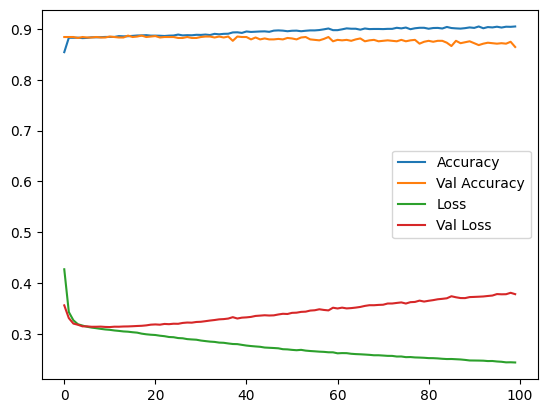

In [26]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'],label='Val Accuracy')
plt.plot(history.history['loss'],label = 'Loss')
plt.plot(history.history['val_loss'], label = 'Val Loss')
plt.legend()

In [ ]:
X.shape

(255347, 18)

In [ ]:
X